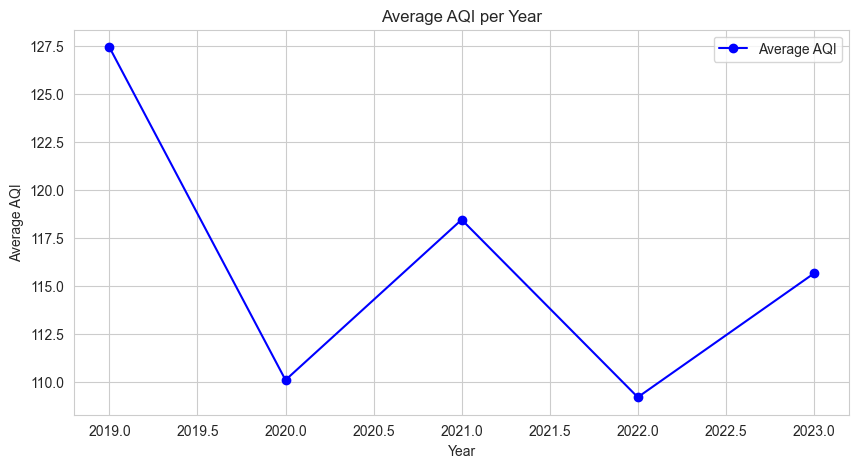

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("final_.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Year"] = df["Timestamp"].dt.year
aqi_per_year = df.groupby("Year")["AQI"].mean()
plt.figure(figsize=(10, 5))
plt.plot(aqi_per_year.index, aqi_per_year.values, marker='o', linestyle='-', color='b', label="Average AQI")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.title("Average AQI per Year")
plt.grid(True)
plt.legend()
plt.show()


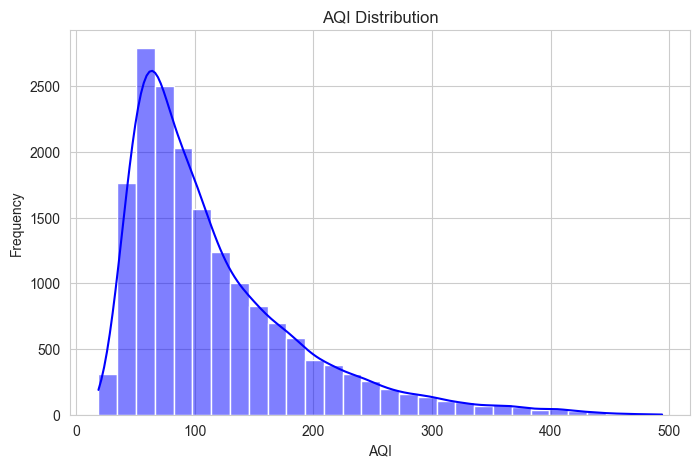

In [6]:
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(df["AQI"], bins=30, kde=True, color="blue")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("AQI Distribution")
plt.show()

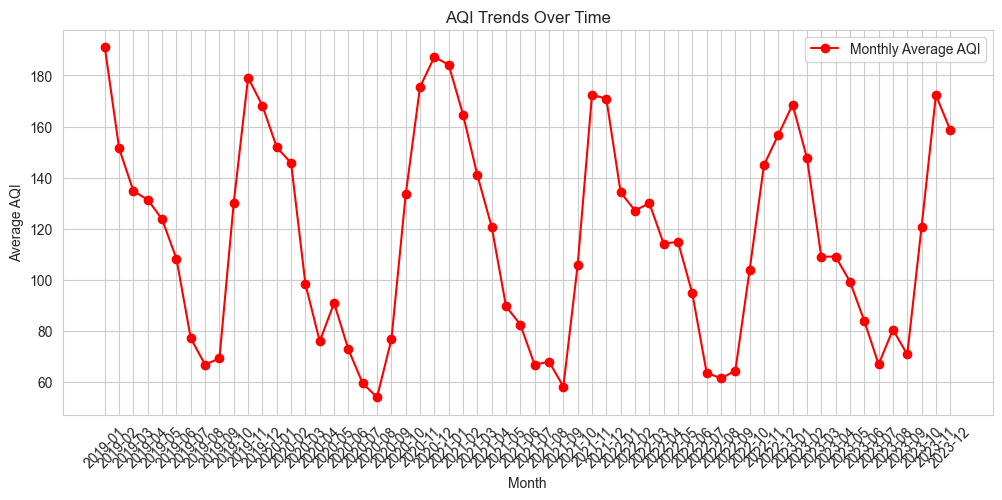

In [7]:
# 2. AQI Trends Over Time (Monthly Mean AQI)
df["Month"] = df["Timestamp"].dt.to_period("M")  # Extract Year-Month
monthly_aqi = df.groupby("Month")["AQI"].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_aqi.index.astype(str), monthly_aqi.values, marker='o', linestyle='-', color='r', label="Monthly Average AQI")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("AQI Trends Over Time")
plt.legend()
plt.show()

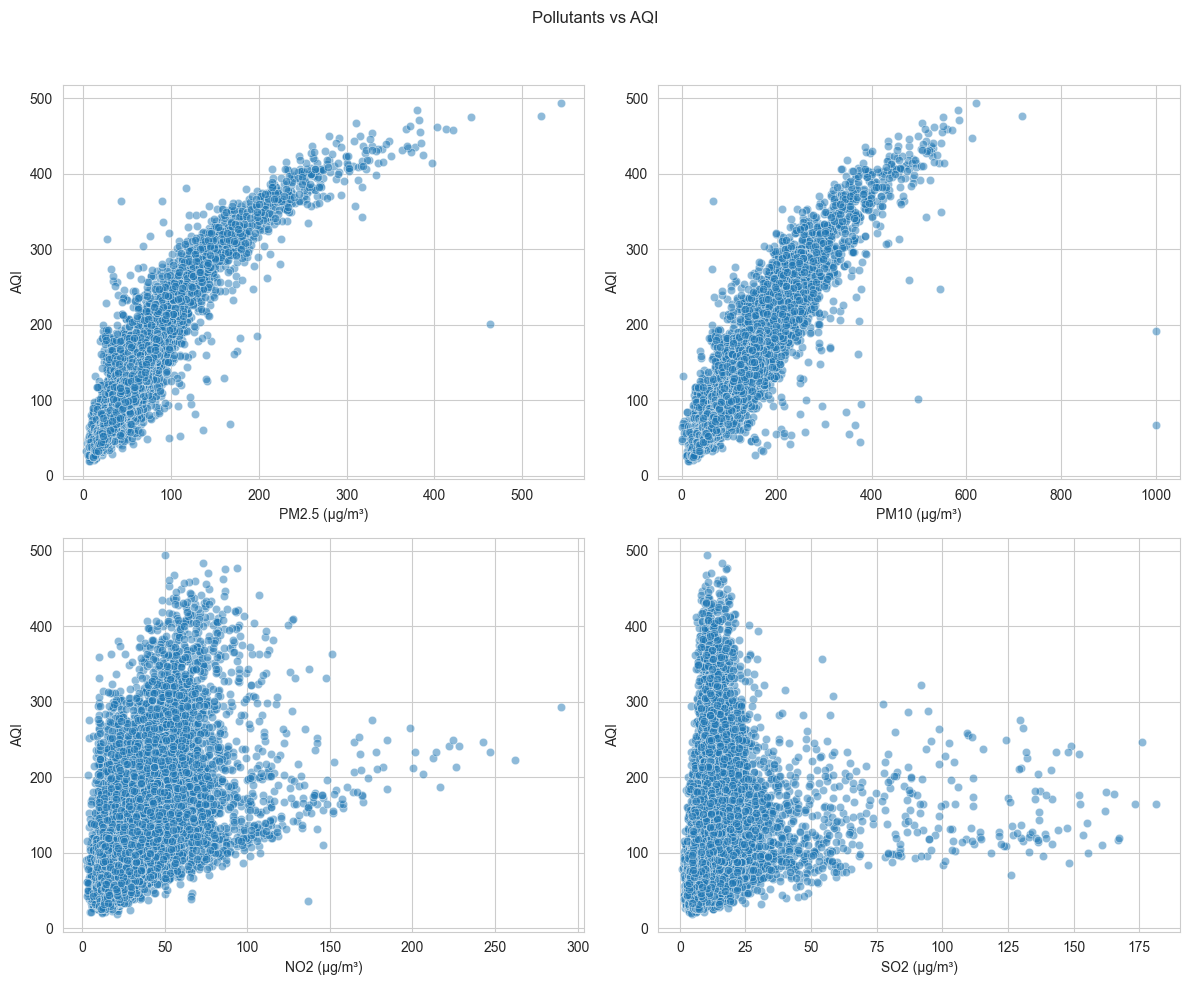

In [8]:
# 3. Pollutants vs. AQI (Scatter Plots)
pollutants = ["PM2.5 (µg/m³)", "PM10 (µg/m³)", "NO2 (µg/m³)", "SO2 (µg/m³)"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Pollutants vs AQI")

for ax, pollutant in zip(axes.flatten(), pollutants):
    sns.scatterplot(x=df[pollutant], y=df["AQI"], ax=ax, alpha=0.5)
    ax.set_xlabel(pollutant)
    ax.set_ylabel("AQI")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


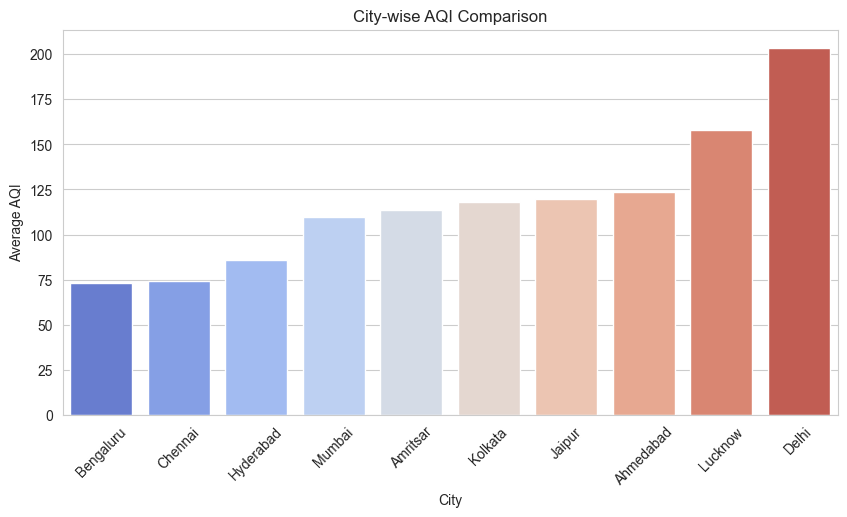

In [9]:
if "City" in df.columns and df["City"].nunique() > 1:
    city_aqi = df.groupby("City")["AQI"].mean().sort_values()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=city_aqi.index, y=city_aqi.values, palette="coolwarm")
    plt.xlabel("City")
    plt.ylabel("Average AQI")
    plt.title("City-wise AQI Comparison")
    plt.xticks(rotation=45)
    plt.show()
